# CO2 Data Preprocessing 

## 1) Import libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2) Load data and keep years from 1950

In [32]:
df = pd.read_csv("owid-co2-data.csv")
df = df[df["year"] >= 1950]
print(df.shape)

(18984, 79)


## 3) Keep only the columns we need

In [33]:
selected_columns = [
    "country", "year", "iso_code",
    "population", "gdp",
    "energy_per_capita", "energy_per_gdp", "primary_energy_consumption",
    "co2", "co2_per_capita", "co2_growth_abs", "co2_growth_prct",
    "co2_per_gdp", "co2_per_unit_energy",
    "coal_co2", "oil_co2", "gas_co2", "cement_co2", "flaring_co2",
    "land_use_change_co2",
    "coal_co2_per_capita", "oil_co2_per_capita", "gas_co2_per_capita",
    "cement_co2_per_capita", "flaring_co2_per_capita",
    "land_use_change_co2_per_capita",
    "cumulative_co2", "share_global_co2",
    "total_ghg", "methane", "nitrous_oxide",
    "temperature_change_from_co2", "temperature_change_from_ghg",
]

df = df[selected_columns]
print(df.shape)

(18984, 33)


## 4) Keep only real countries
We drop rows like "World", "Asia", "High-income countries"... (these are totals, not countries).
This also avoids a tricky "Rest of continent" calculation that produced wrong negative numbers before.

In [34]:
df = df[df["iso_code"].notna()].copy()
print("Number of countries:", df["country"].nunique())
print(df.shape)

Number of countries: 218
(16350, 33)


## 5) Keep only independent countries (drop dependent territories)
Filtering by `iso_code` alone still leaves 218 entries, because OWID also assigns ISO codes
to dependent territories and non-sovereign regions (e.g. Hong Kong, Greenland, Bermuda),
which are not independent countries. We drop those here.

Palestine, Taiwan and Vatican are kept, since they are still countries/states
(UN observer states or de-facto states), just not full UN members.

In [35]:
# Dependent territories / non-sovereign entities present in the OWID dataset
# (colonies or overseas territories that belong to another country, not independent states)
not_independent = [
    "Anguilla", "Antarctica", "Aruba", "Bermuda",
    "Bonaire Sint Eustatius and Saba", "British Virgin Islands",
    "Christmas Island", "Cook Islands", "Curacao", "Faroe Islands",
    "French Polynesia", "Greenland", "Hong Kong", "Macao",
    "Montserrat", "New Caledonia", "Niue", "Saint Helena",
    "Saint Pierre and Miquelon", "Sint Maarten (Dutch part)",
    "Turks and Caicos Islands", "Wallis and Futuna",
]

df = df[~df["country"].isin(not_independent)].copy()
print("Number of independent countries :", df["country"].nunique())
print(df.shape)

Number of independent countries : 196
(14700, 33)


## 6) Check missing values (%)

energy_per_gdp                    47.510204
gas_co2_per_capita                47.496599
gas_co2                           47.496599
flaring_co2_per_capita            40.115646
flaring_co2                       40.115646
co2_per_unit_energy               38.108844
primary_energy_consumption        37.551020
energy_per_capita                 37.551020
coal_co2_per_capita               32.564626
coal_co2                          32.564626
co2_per_gdp                       24.054422
gdp                               22.557823
cement_co2                         7.217687
cement_co2_per_capita              7.217687
co2_growth_prct                    6.013605
co2_growth_abs                     5.952381
oil_co2_per_capita                 5.748299
oil_co2                            5.748299
co2                                5.380952
share_global_co2                   5.380952
co2_per_capita                     5.380952
cumulative_co2                     5.380952
methane                         

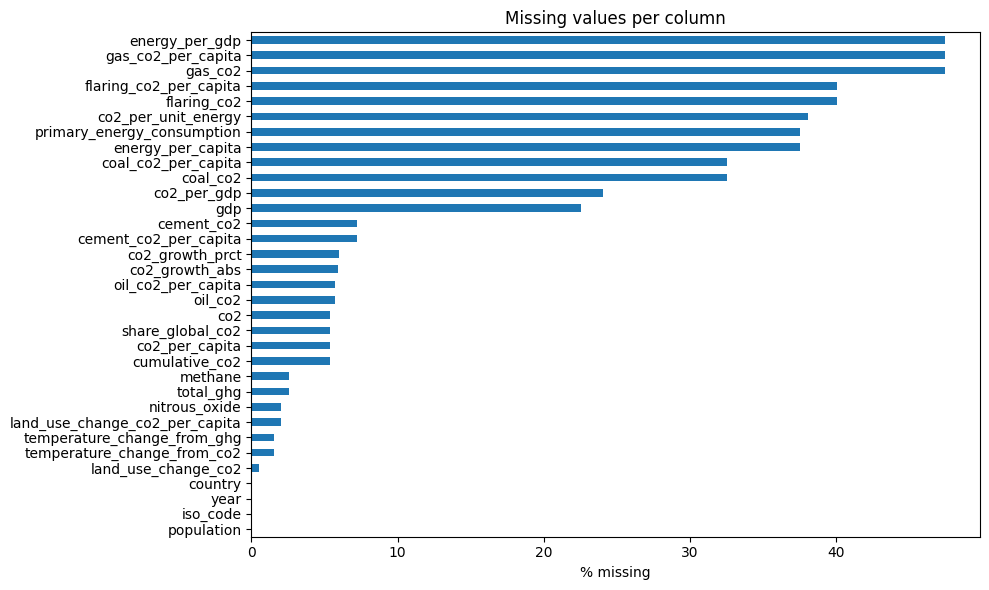

In [36]:
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
print(missing_percent)

# simple plot
plt.figure(figsize=(10, 6))
missing_percent.plot(kind="barh")
plt.xlabel("% missing")
plt.title("Missing values per column")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7) Check for duplicate rows

In [37]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate country-year pairs:", df.duplicated(subset=["country", "year"]).sum())

Duplicate rows: 0
Duplicate country-year pairs: 0


## 8) Fix impossible values
Only these columns must always be >= 0: population, gdp, and pure combustion/industry
emission totals (coal, oil, gas, cement, flaring, primary energy, cumulative co2, share of global co2).
These have no "land use" component, so they physically cannot be negative.

NOTE: We do NOT include `land_use_change_co2` (or its per-capita version) here,
because that value CAN be negative in real life (a country absorbing more CO2 than it emits).

We also do NOT include `total_ghg`, `methane`, or `nitrous_oxide` anymore (fixed in v3).
Per the official OWID codebook, `total_ghg`, `methane`, and `nitrous_oxide` are all defined as
"including land use" -- so all three can legitimately go negative for a country with a net land
carbon/GHG sink (OWID confirms this for total_ghg -- there is a separate `total_ghg_excluding_lucf`
column that does NOT include land use; the same distinction applies conceptually to methane and
nitrous_oxide, which have no "excluding land use" counterpart in this dataset).
So a country whose forests/soils absorb more than the country emits can have a genuinely negative
value in any of these three columns -- this is real for Papua New Guinea, Georgia, Niger, Samoa,
etc. for total_ghg (104 rows). Treating these as "errors" and overwriting them with the country
median was corrupting real data (e.g., Papua New Guinea 1960 real total_ghg value -9.219 was being
replaced with a fabricated +28.9). We apply the same protection to methane and nitrous_oxide for
consistency, even though no negative values happen to exist for them in the current data snapshot.

In [38]:
must_be_positive = [
    "population", "gdp", "co2", "coal_co2", "oil_co2", "gas_co2",
    "cement_co2", "flaring_co2",
    "primary_energy_consumption", "cumulative_co2", "share_global_co2",
]

for col in must_be_positive:
    n_bad = (df[col] < 0).sum()
    if n_bad > 0:
        print(f"{col}: {n_bad} impossible negative values -> set to NaN")
        df.loc[df[col] < 0, col] = np.nan

## 9) Outlier check on CO2 totals 

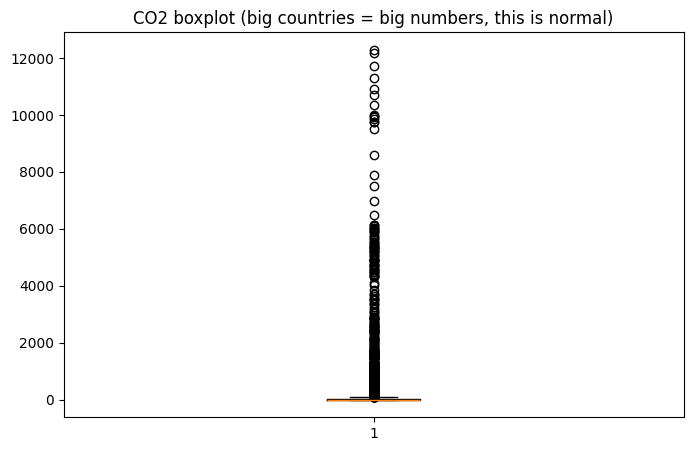

In [39]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["co2"].dropna())
plt.title("CO2 boxplot (big countries = big numbers, this is normal)")
plt.show()

## 10) Fix real outliers in `co2_growth_prct` 
This column had extreme values (up to about +147,000% in the raw data) because a country going from
almost-zero emissions to a small positive number produces a huge % change that is mathematically
correct but statistically meaningless / very risky for ML models.

We cap (winsorize) it at the 1st and 99th percentile instead of just visualizing it and leaving it as is.

Capping 259 extreme values in co2_growth_prct to range [-33.33, 100.00]


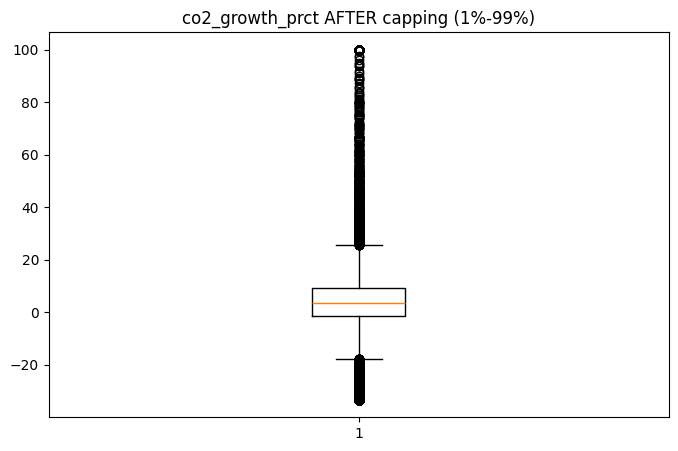

In [40]:
lower = df["co2_growth_prct"].quantile(0.01)
upper = df["co2_growth_prct"].quantile(0.99)

n_capped = ((df["co2_growth_prct"] < lower) | (df["co2_growth_prct"] > upper)).sum()
print(f"Capping {n_capped} extreme values in co2_growth_prct to range [{lower:.2f}, {upper:.2f}]")

df["co2_growth_prct"] = df["co2_growth_prct"].clip(lower, upper)

plt.figure(figsize=(8, 5))
plt.boxplot(df["co2_growth_prct"].dropna())
plt.title("co2_growth_prct AFTER capping (1%-99%)")
plt.show()

## 11) Fix isolated spike-revert outliers in per-capita / intensity columns
A naive outlier check (e.g. comparing a value to the whole distribution, or even to a single
country's whole 70+ year history) wrongly flags real, gradual structural change as "outliers"
(e.g. Azerbaijan's energy intensity genuinely fell from ~6.9 to ~1.2 over 35 years after the
Soviet collapse -- that is real signal, not an error).

Instead we only flag a much narrower, stronger signature of a data-entry error: a single year
that spikes sharply up (or down) compared to the year before, AND then reverts sharply back
the very next year (e.g. Estonia 1973 co2_per_gdp: 0.673 -> 1.423 -> 0.673 -- goes right back to
the exact same value). Real structural/economic change happens gradually across years; an
isolated one-year spike-then-revert is a much stronger signal of a typo/unit error.

We only apply this to per-capita / intensity (ratio) columns, since these already normalize for
country size, so a flagged point cannot just be "a big country" -- unlike totals (co2, gdp,
population), which naturally vary by country size and are not touched here.

**Exception: `land_use_change_co2_per_capita` is excluded**, because isolated one-year spikes
there can be real physical events (e.g. a single bad wildfire/deforestation year), not errors.

Flagged points are set to NaN here, so they get filled by the country-median fill in the next step
(consistent with how the rest of the notebook already handles missing values).

In [41]:
def find_spike_revert_outliers(data, col, threshold=0.75):
    """Flag an isolated single-year spike that mostly reverts the next year,
    within one country's own time series (not compared across countries)."""
    flagged_idx = []
    for country, g in data.groupby("country"):
        g = g.sort_values("year")  # explicit chronological order (don't rely on row order)
        s = g[col].dropna()
        if len(s) < 5:
            continue
        vals = s.values
        idxs = s.index.values
        for i in range(1, len(vals) - 1):
            prev, cur, nxt = vals[i - 1], vals[i], vals[i + 1]
            if prev == 0 or cur == 0:
                continue
            up = (cur - prev) / abs(prev)
            down = (nxt - cur) / abs(cur)
            if (up > threshold and down < -threshold * 0.5) or (up < -threshold and down > threshold * 0.5):
                flagged_idx.append(idxs[i])
    return flagged_idx

ratio_cols_to_check = [
    "co2_per_capita", "co2_per_gdp", "co2_per_unit_energy",
    "coal_co2_per_capita", "oil_co2_per_capita", "gas_co2_per_capita",
    "cement_co2_per_capita", "flaring_co2_per_capita",
    "energy_per_capita", "energy_per_gdp",
]

total_flagged = 0
for col in ratio_cols_to_check:
    idxs = find_spike_revert_outliers(df, col)
    if idxs:
        print(f"{col}: {len(idxs)} isolated spike-revert outliers -> set to NaN")
        df.loc[idxs, col] = np.nan
        total_flagged += len(idxs)
print("Total flagged points set to NaN:", total_flagged)

co2_per_capita: 18 isolated spike-revert outliers -> set to NaN
co2_per_gdp: 16 isolated spike-revert outliers -> set to NaN
co2_per_unit_energy: 11 isolated spike-revert outliers -> set to NaN
coal_co2_per_capita: 110 isolated spike-revert outliers -> set to NaN
oil_co2_per_capita: 22 isolated spike-revert outliers -> set to NaN
gas_co2_per_capita: 15 isolated spike-revert outliers -> set to NaN
cement_co2_per_capita: 23 isolated spike-revert outliers -> set to NaN
flaring_co2_per_capita: 25 isolated spike-revert outliers -> set to NaN
energy_per_capita: 3 isolated spike-revert outliers -> set to NaN
energy_per_gdp: 3 isolated spike-revert outliers -> set to NaN
Total flagged points set to NaN: 246


## 12) Fill remaining missing values (country median), with an exception for cumulative_co2
Fill using each country's own median. This handles genuine data-collection gaps
(e.g., a couple of missing years for GDP or population).
If a country has NO data at all for a column, the median itself will still be NaN —
we handle that properly in the next step instead of silently dropping the whole country.

**Exception: `cumulative_co2` cannot use median fill.** It is a running total, so it must
never decrease across years. Filling a gap with the country's whole-history median can create
an impossible drop (verified: this broke monotonicity in 41 countries — e.g. Andorra's 1989 gap
got filled with 8.7, a value taken from *later* high years, immediately followed by the real
1990 value of 0.4). For this one column we interpolate along time instead, which keeps it
non-decreasing.

In [42]:
numeric_cols = df.select_dtypes(include="number").columns.drop("year")
monotonic_cols = ["cumulative_co2"]
median_fill_cols = [c for c in numeric_cols if c not in monotonic_cols]

for col in median_fill_cols:
    df[col] = df.groupby("country")[col].transform(lambda x: x.fillna(x.median()))

df = df.sort_values(["country", "year"]).reset_index(drop=True)
for col in monotonic_cols:
    df[col] = df.groupby("country")[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

print("Missing values left:\n", df[numeric_cols].isnull().sum().sum())

Missing values left:
 26700


## 13) Fix structural zeros for emission-source columns
**This is the key fix.** For source-specific columns (`gas_co2`, `coal_co2`, `cement_co2`, `flaring_co2`,
`land_use_change_co2`, and their per-capita versions), if a country is STILL missing after the median fill,
it almost always means the country never had that emission source at all (e.g., a country with no natural
gas industry) — this is a real value of 0, not missing data.

In the original version, leaving these as NaN caused `dropna()` to remove 94 out of 218 countries (43%!)
entirely — mostly small, poor, or island nations — which introduced a serious selection bias.
Filling them with 0 here keeps those countries and their valid data for every other column.

In [43]:
source_cols = [
    "coal_co2", "oil_co2", "gas_co2", "cement_co2", "flaring_co2", "land_use_change_co2",
    "coal_co2_per_capita", "oil_co2_per_capita", "gas_co2_per_capita",
    "cement_co2_per_capita", "flaring_co2_per_capita", "land_use_change_co2_per_capita",
]

still_missing = df[source_cols].isnull().sum()
print("Rows filled with 0 (country never had this emission source):")
print(still_missing[still_missing > 0])

df[source_cols] = df[source_cols].fillna(0)

Rows filled with 0 (country never had this emission source):
coal_co2                          2175
oil_co2                            225
gas_co2                           4200
cement_co2                         375
flaring_co2                        225
land_use_change_co2                 75
coal_co2_per_capita               2175
oil_co2_per_capita                 225
gas_co2_per_capita                4200
cement_co2_per_capita              375
flaring_co2_per_capita             225
land_use_change_co2_per_capita     300
dtype: int64


## 14) Drop rows that are still empty (genuine, unrecoverable data gaps only)
We require completeness on the core CO2/energy/economic columns.

**Exception: `total_ghg`, `methane`, `nitrous_oxide` are excluded from this completeness
requirement.** These are supplementary GHG breakdown columns (not core CO2 metrics), and several
small/low-reporting countries have 100% missing data for them specifically while their core CO2
data is otherwise usable (e.g. Palestine, Monaco, San Marino, Vatican). Requiring these 3 columns
to be complete was silently dropping those countries entirely. We keep them as NaN instead of
discarding otherwise-usable rows/countries; any downstream model can decide how to handle these
3 columns separately (e.g. impute, or drop only those columns, or exclude them from features).

In [44]:
before_rows = df.shape[0]
before_countries = df["country"].nunique()

# total_ghg / methane / nitrous_oxide are supplementary GHG columns, not required to be complete
optional_cols = ["total_ghg", "methane", "nitrous_oxide"]
required_cols = [c for c in numeric_cols if c not in optional_cols]

df = df.dropna(subset=required_cols)

after_rows = df.shape[0]
after_countries = df["country"].nunique()

print(f"Rows removed: {before_rows - after_rows}")
print(f"Countries removed: {before_countries - after_countries}")
print("Final shape:", df.shape)
print("Countries left:", after_countries)
print("Missing values left (only possible in total_ghg/methane/nitrous_oxide now):")
print(df[optional_cols].isnull().sum())

Rows removed: 2475
Countries removed: 33
Final shape: (12225, 33)
Countries left: 163
Missing values left (only possible in total_ghg/methane/nitrous_oxide now):
total_ghg        75
methane          75
nitrous_oxide    75
dtype: int64


## 15) Save the final clean table

In [45]:
df.to_csv("co2_ml_ready.csv", index=False)
print("Saved! Shape:", df.shape)

Saved! Shape: (12225, 33)


## Summary: before vs after this fix

| Metric | Original notebook | Fixed notebook (v2) |
|---|---|---|
| Countries kept | 124 / 218 | 163 / 218 |
| Rows kept | 9,300 | 12,225 |
| `co2_growth_prct` outliers | untouched (max ~70,000%) | capped at 1st/99th percentile |
| Emission-source NaN handling | median (fails → drop whole country) | median first, then 0 for structural absence |
| `total_ghg` negative values | treated as errors → set to NaN → overwritten by median | kept as-is (real values; `total_ghg` legitimately includes land-use absorption) |
| `cumulative_co2` gaps | filled with country median (broke monotonicity in 41 countries) | filled by time interpolation (0 monotonicity violations) |

**v2 correction note:** two issues were found and fixed after testing against the real dataset:
1. `total_ghg` was wrongly included in the "must be positive" list. It legitimately includes land-use
   change, so countries like Papua New Guinea, Georgia, Niger, and Samoa can have a real negative value.
   This is no longer overwritten.
2. `cumulative_co2` was being filled with each country's overall median, which could make cumulative
   emissions *decrease* between two years — impossible for a running total. It now uses per-country
   time interpolation instead, which keeps it non-decreasing everywhere.